# Driver Drowsiness EEG Preprocessing Check

This notebook loads `dataset.mat`, checks its structure, converts the segmented EEG windows into an MNE `EpochsArray`, and plots labeled snapshots of the EEG channels to confirm the data loaded correctly.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.io import loadmat

mne.set_log_level("WARNING")

## Load the MAT Dataset

The file stores already-windowed EEG data:

- `EEGsample`: EEG windows with shape `(samples, channels, time)`
- `substate`: binary labels, where `0 = alert` and `1 = drowsy`
- `subindex`: subject IDs

In [30]:
dataset_candidates = [
    Path("dataset.mat"),
    Path("data/driver-drowsiness/dataset.mat"),
]

dataset_path = next((path for path in dataset_candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find dataset.mat. Run this notebook from the repo root or data/driver-drowsiness.")

mat = loadmat(dataset_path)

X = mat["EEGsample"].astype(np.float32)      # (samples, channels, time)
y = mat["substate"].reshape(-1).astype(int)  # 0 = alert, 1 = drowsy
subjects = mat["subindex"].reshape(-1).astype(int)

label_names = {0: "alert", 1: "drowsy"}

print(f"Loaded: {dataset_path}")
print(f"X shape: {X.shape}  # samples x channels x time")
print(f"y shape: {y.shape}")
print(f"subjects shape: {subjects.shape}")
print(f"value range: {X.min():.2f} to {X.max():.2f}")
print(f"mean/std: {X.mean():.4f} / {X.std():.4f}")

Loaded: dataset.mat
X shape: (2022, 30, 384)  # samples x channels x time
y shape: (2022,)
subjects shape: (2022,)
value range: -3195.43 to 3430.91
mean/std: -0.0329 / 20.0149


## Dataset Summary

In [31]:
summary = pd.DataFrame({
    "subject": subjects,
    "label": y,
    "state": [label_names[label] for label in y],
})

display(summary.head())

print("Overall label counts:")
display(summary["state"].value_counts().rename_axis("state").to_frame("count"))

print("Per-subject label counts:")
display(pd.crosstab(summary["subject"], summary["state"]))

,subject,label,state
0,1,0,alert
1,1,0,alert
2,1,0,alert
3,1,0,alert
4,1,0,alert


Overall label counts:


,count
state,
alert,1011
drowsy,1011


Per-subject label counts:


state,alert,drowsy
subject,,
1,94,94
2,66,66
3,75,75
4,74,74
5,112,112
6,83,83
7,51,51
8,132,132
9,157,157


## Convert to MNE Epochs

MNE expects EEG voltages in volts. This dataset is commonly distributed in microvolt-like units, so the MNE object below uses `X * 1e-6`. For plotting raw values from the MAT file, the notebook keeps using `X` directly because those amplitudes are easier to read as microvolts.

In [32]:
sfreq = 128
ch_names = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FT7", "FC3", "FCz", "FC4", "FT8",
    "T3", "C3", "Cz", "C4", "T4",
    "TP7", "CP3", "CPz", "CP4", "TP8",
    "T5", "P3", "Pz", "P4", "T6",
    "O1", "Oz", "O2",
]

if X.shape[1] != len(ch_names):
    raise ValueError(f"Expected {len(ch_names)} channels, found {X.shape[1]} channels.")

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
info.set_montage("standard_1020", on_missing="ignore")

# MNE event IDs are kept positive; original labels remain in metadata.
events = np.column_stack([
    np.arange(len(y)) * X.shape[2],
    np.zeros(len(y), dtype=int),
    y + 1,
])
event_id = {"alert": 1, "drowsy": 2}
metadata = pd.DataFrame({"subject": subjects, "label": y, "state": [label_names[label] for label in y]})

epochs = mne.EpochsArray(
    X * 1e-6,
    info,
    events=events,
    event_id=event_id,
    tmin=0.0,
    metadata=metadata,
    verbose="WARNING",
)

epochs

<EpochsArray | 2022 events (all good), 0 – 2.992 s (baseline off), ~177.8 MiB, data loaded, with metadata,
 'alert': 1011
 'drowsy': 1011>

## Broad Channel Snapshot

Each plot below shows one 3-second EEG window. The title includes the sample index, subject ID, and label.

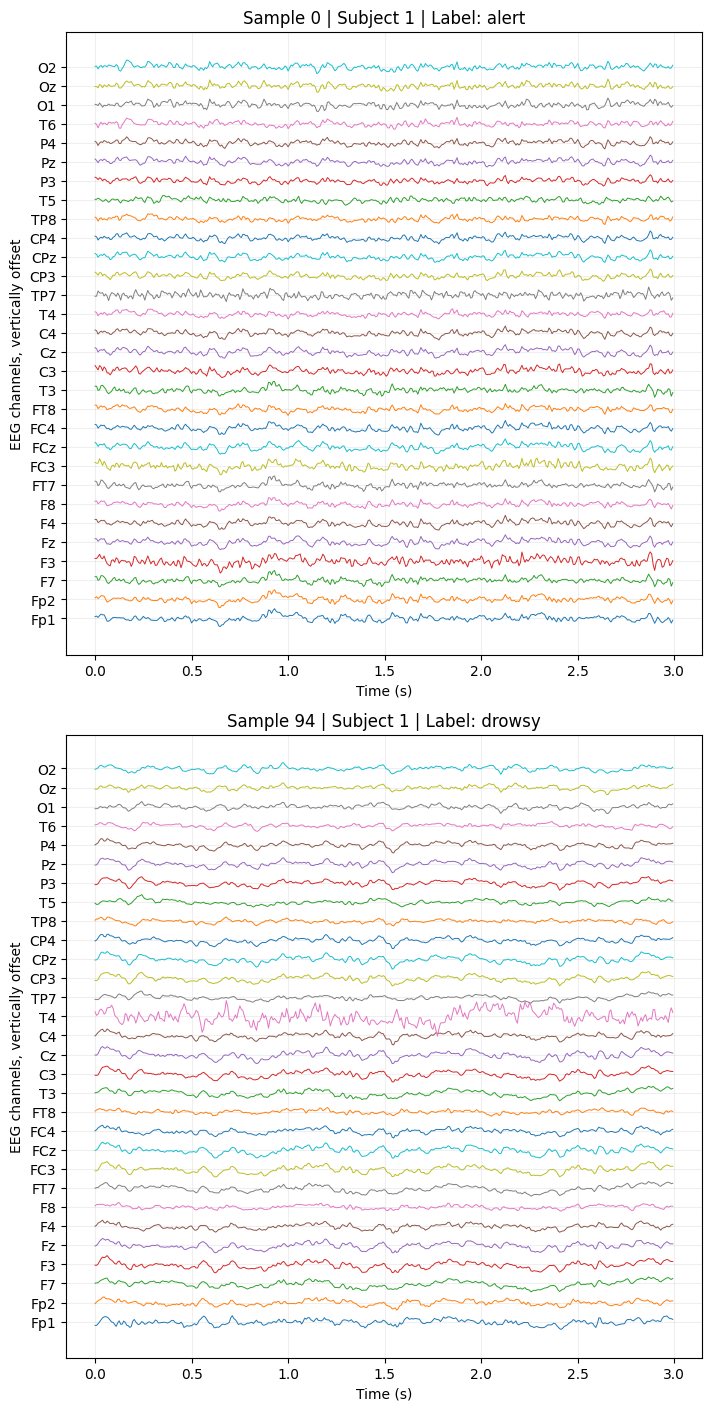

In [33]:
def plot_epoch_snapshot(epoch_idx, max_channels=30, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 9))

    data = X[epoch_idx, :max_channels]
    times = np.arange(data.shape[1]) / sfreq

    # Use a robust channel spacing so one large artifact does not flatten the plot.
    ptp = np.ptp(data, axis=1)
    offset_step = max(np.percentile(ptp, 75) * 1.25, 1.0)
    offsets = np.arange(data.shape[0]) * offset_step

    state = label_names[y[epoch_idx]]
    subject = subjects[epoch_idx]

    for channel_idx, trace in enumerate(data):
        ax.plot(times, trace + offsets[channel_idx], linewidth=0.7)

    ax.set_title(f"Sample {epoch_idx} | Subject {subject} | Label: {state}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EEG channels, vertically offset")
    ax.set_yticks(offsets)
    ax.set_yticklabels(ch_names[:max_channels])
    ax.grid(alpha=0.2)

    return ax


example_alert = int(np.where(y == 0)[0][0])
example_drowsy = int(np.where(y == 1)[0][0])

fig, axes = plt.subplots(2, 1, figsize=(7, 14), constrained_layout=True)
plot_epoch_snapshot(example_alert, ax=axes[0])
plot_epoch_snapshot(example_drowsy, ax=axes[1])
plt.show()

## Random Labeled Snapshots

This gives a quick visual sanity check across multiple subjects and labels.

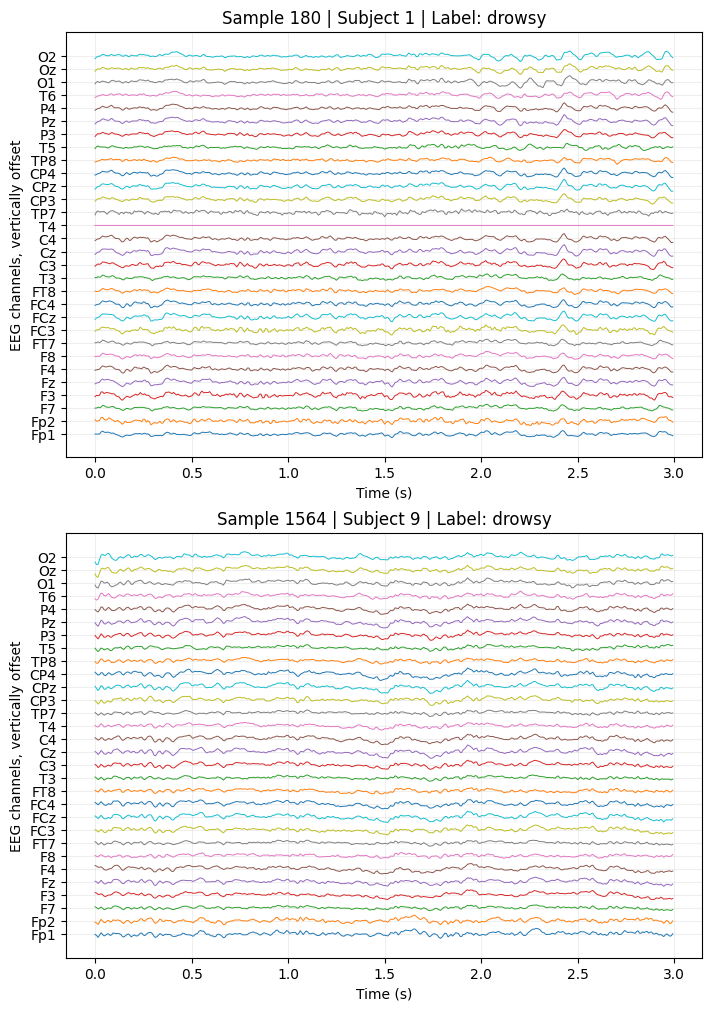

In [34]:
rng = np.random.default_rng(42)
random_indices = rng.choice(np.arange(len(X)), size=2, replace=False)

fig, axes = plt.subplots(2, 1, figsize=(7, 10), constrained_layout=True)
for epoch_idx, ax in zip(random_indices, axes):
    plot_epoch_snapshot(int(epoch_idx), max_channels=30, ax=ax)

plt.show()

## Tensor Format for Modeling

For PyTorch-style classifiers, the useful arrays are already available as:

- `X`: `(samples, channels, time)`
- `y`: `(samples,)`
- `subjects`: `(samples,)`

This is the format we should make future datasets match after preprocessing.

In [35]:
X_model = X.astype(np.float32)
y_model = y.astype(np.int64)

print("X_model:", X_model.shape, X_model.dtype)
print("y_model:", y_model.shape, y_model.dtype)
print("subjects:", subjects.shape, subjects.dtype)

X_model: (2022, 30, 384) float32
y_model: (2022,) int64
subjects: (2022,) int64
